# Resolving Multi-Mapping Reads using Expectation-Maximization (EM)

This notebook implements the Expectation-Maximization (EM) algorithm to resolve ambiguous, multi-mapping RNA-seq reads across highly repetitive genomic features (e.g., L1 insertions).

By treating the true genomic origin of a read as a latent variable, we can use an iterative probabilistic framework to rescue ambiguous reads based on sequence alignment scores and the overall expression weight of each feature.

## 1. Problem Formulation & Variables

Let $N$ be the total number of sequenced reads and $M$ be the total number of candidate genomic features (insertions).

* **$L$ (The Likelihood Matrix):**
An $N \times M$ matrix where $l_{ij}$ represents the sequence alignment likelihood (or score) that read $i$ originated from feature $j$. A score of $1.0$ indicates a perfect match, while lower scores represent mismatch penalties.
* **$\theta$ (The Prior Weights):** 
A vector of length $M$ representing our current estimate of the relative abundance (or activity level) of each feature. Initialized uniformly as $\theta_j = 1/M$.
* **$Z$ (The Posterior Matrix):** 
An $N \times M$ matrix where $Z_{ij}$ is the calculated fractional probability that read $i$ belongs to feature $j$, given the sequence evidence and our current weights.

## 2. The EM Algorithm

The algorithm alternates between two steps until the parameters ($\theta$) converge to a stable equilibrium.

### The Expectation Step (E-Step)
For every read, we calculate the posterior probability that it originated from each specific feature. This is done by multiplying the sequence likelihood by the feature's prior weight, and normalizing across all possible features for that read.

$$Z_{ij}=\frac{l_{ij}\theta_j}{\sum_{k=1}^{M}l_{ik}\theta_k}$$

### The Maximization Step (M-Step)
We update our prior weights ($\theta$) for the next iteration. We sum all the fractional read allocations for each feature to get the new expected read counts, and divide by the total number of reads to convert them back into probabilities.

$$\theta_j^{(new)}=\frac{\sum_{i=1}^{N}Z_{ij}}{N}$$

## 3. The "No Dynamics" Caveat (The Importance of Anchors and Alignment Penalties)

For this algorithm to learn the true distribution, there **must** be asymmetry in the Likelihood Matrix ($L$). This asymmetry comes from:
1.  **Unique "Anchor" Reads:** Reads that map exclusively to one feature.
2.  **Alignment Penalties:** Variations in edit-distance scores across different features.

**If all reads map equally well to all features** (i.e., $l_{ij}$ is a constant $c$ for all features), the E-step simplifies to $Z_{ij} = \theta_j$. Consequently, the M-step simply returns the exact same $\theta$ we started with. Under perfectly uniform ambiguity, the algorithm exhibits **zero dynamics**—it will perpetually divide the reads equally and fail to converge on a meaningful biological distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate 1000 reads
Simulate the reads to be mapped almost equally well to 5 L1 insertions but:
* Anchor reads map strictly uniquely to certain L1 insertions.
* Alignment penalties reads have a mismatchs to certain L1 insertions

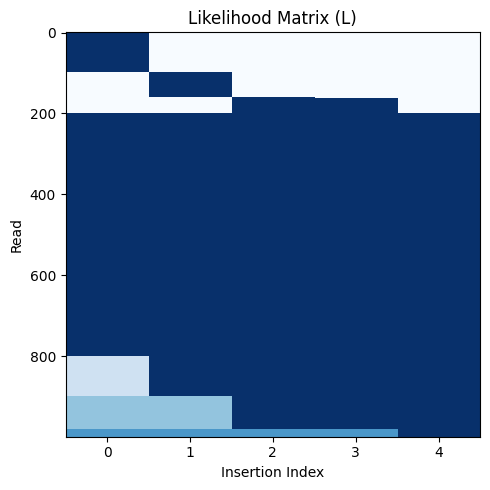

In [2]:
# 5 L1 insertions
num_insertions = 5

# 100 reads map strictly uniquely to L1_1
unique_L1_0 = np.zeros((100, num_insertions))
unique_L1_0[:, 0] = 1

# 60 reads map strictly uniquely to L1_2
unique_L1_1 = np.zeros((60, num_insertions))
unique_L1_1[:, 1] = 1

# 2 reads map strictly uniquely to L1_3
unique_L1_2 = np.zeros((2, num_insertions))
unique_L1_2[:, 2] = 1

# 38 reads map strictly uniquely to L1_3 and L1_4
unique_L1_3 = np.zeros((38, num_insertions))
unique_L1_3[:, 2:4] = 1

# 600 reads map perfectly to all 5 (score = 1.0)
perfect_multi = np.ones((600, num_insertions))

# 200 reads have a mismatch penalty for the heavyweights
skewed_multi = np.ones((200, num_insertions))
skewed_multi[:100, 0] = 0.2
skewed_multi[100:180, 0:2] = 0.4
skewed_multi[180:200, 0:4] = 0.6

# Combine into our Likelihood Matrix (L)
L = np.vstack([unique_L1_0, unique_L1_1, unique_L1_2, unique_L1_3, perfect_multi, skewed_multi])
num_reads = L.shape[0]

# Plot the Likelihood Matrix (L)
fig, ax = plt.subplots(figsize=(5, 5))
lcax = ax.imshow(L, aspect='auto', cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
ax.set_title('Likelihood Matrix (L)')
ax.set_xlabel('Insertion Index')
ax.set_ylabel('Read')
plt.tight_layout()
plt.show()

# Initialize the Expectaion Maximization EM algorithm
initialize the theta values to be uniform 20% each (uniform prior)

In [3]:
# Start with uniform prior assumption: all L1s are equally active (20% each)
theta = np.ones(num_insertions) / num_insertions

print(f"Initial Theta: {theta.round(3)}\n")

Initial Theta: [0.2 0.2 0.2 0.2 0.2]



# THE EM LOOP
Perform the EM algorithm for 600 iterations

In [4]:
thetas = []
iterations = 600
for step in range(iterations):
    # Append the current theta to the list
    thetas.append(theta)
    
    # E-STEP: Calculate fractional allocations (Z matrix)
    # Multiply the binary indicator matrix by our current weights
    numerator = L * theta
    
    # Divide by the row sums to normalize probabilities per read
    denominator = numerator.sum(axis=1, keepdims=True)
    Z = numerator / denominator
    
    # M-STEP: Update Theta based on the new fractional counts
    expected_counts = Z.sum(axis=0)
    theta = expected_counts / num_reads

    if step % 50 == 0 or step == iterations - 1:
        print(f"Iteration {step}: {theta.round(3)}")

print(f"\nFinal Expected Counts per L1: {expected_counts.round(1)}")

Iteration 0: [0.237 0.216 0.189 0.187 0.171]
Iteration 50: [0.333 0.313 0.222 0.131 0.001]
Iteration 100: [0.333 0.313 0.255 0.099 0.   ]
Iteration 150: [0.333 0.313 0.279 0.075 0.   ]
Iteration 200: [0.333 0.313 0.298 0.056 0.   ]
Iteration 250: [0.333 0.313 0.311 0.042 0.   ]
Iteration 300: [0.333 0.313 0.322 0.032 0.   ]
Iteration 350: [0.333 0.313 0.33  0.024 0.   ]
Iteration 400: [0.333 0.313 0.336 0.018 0.   ]
Iteration 450: [0.333 0.313 0.34  0.014 0.   ]
Iteration 500: [0.333 0.313 0.344 0.01  0.   ]
Iteration 550: [0.333 0.313 0.346 0.008 0.   ]
Iteration 599: [0.333 0.313 0.348 0.006 0.   ]

Final Expected Counts per L1: [332.8 313.4 347.9   5.9   0. ]


# Plot the evolution of the theta weights

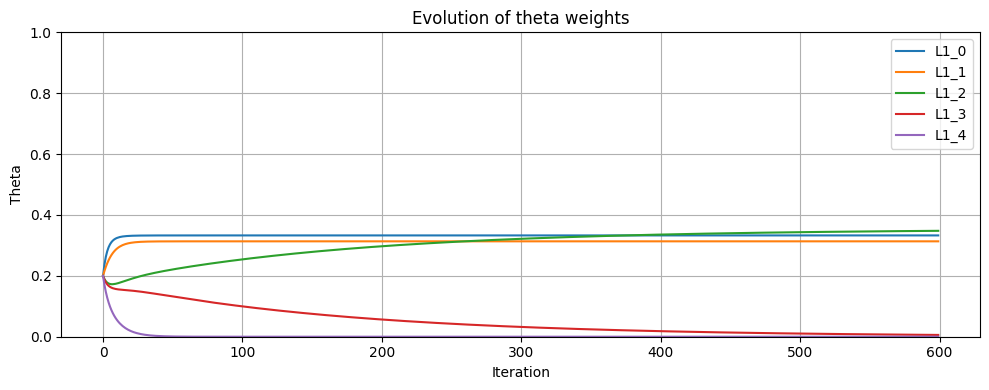

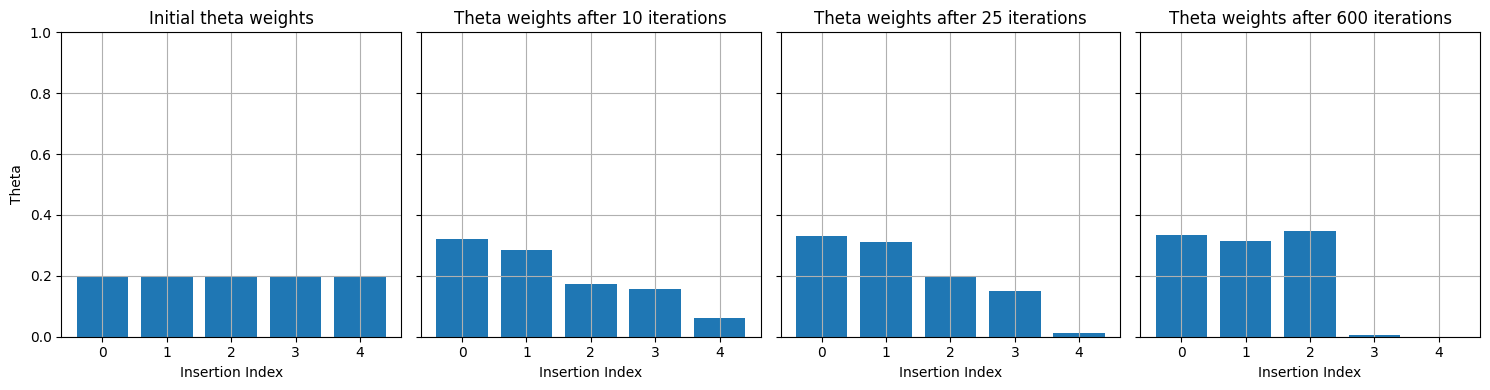

In [5]:
# Plot the theta weights
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thetas, label=['L1_0', 'L1_1', 'L1_2', 'L1_3', 'L1_4'])
ax.set_title('Evolution of theta weights')
ax.set_xlabel('Iteration')
ax.set_ylabel('Theta')
ax.set_ylim(0, 1)
ax.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# plot the initial theta
fig, ax = plt.subplots(1, 4,figsize=(15, 4), sharey=True)
ax[0].bar(range(num_insertions), thetas[0])
ax[0].set_title('Initial theta weights')
ax[0].set_xlabel('Insertion Index')
ax[0].set_ylabel('Theta')
ax[0].set_ylim(0, 1)
ax[0].grid(True)

ax[1].bar(range(num_insertions), thetas[9])
ax[1].set_title('Theta weights after 10 iterations')
ax[1].set_xlabel('Insertion Index')
ax[1].grid(True)

ax[2].bar(range(num_insertions), thetas[24])
ax[2].set_title('Theta weights after 25 iterations')
ax[2].set_xlabel('Insertion Index')
ax[2].grid(True)

ax[3].bar(range(num_insertions), thetas[-1])
ax[3].set_title(f'Theta weights after {iterations} iterations')
ax[3].set_xlabel('Insertion Index')
ax[3].grid(True)
plt.tight_layout()

plt.show()

Theta wheight for L1_2 decresed at the first 10 iterations, but finished at the top.